In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
from utils.metrics import train_feature_weighted_random_forest
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import  mrs, mrs_without_cv
from weighting_methods.maximum_representative_subsampling import mrs_step
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weights, compute_feature_weights_with_temperature
from utils.metrics import compute_test_metrics_fw_mrs, train_random_forest_classifier_mrs, compute_test_metrics_mrs


2024-08-15 16:39:31.421874: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-15 16:39:32.373374: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)
feature_weights = np.ones(len(columns)) / len(columns)

In [3]:
_, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20, feature_weights=feature_weights)
# drop_ids, feature_importance = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20, feature_weight=feature_weights)

<Axes: >

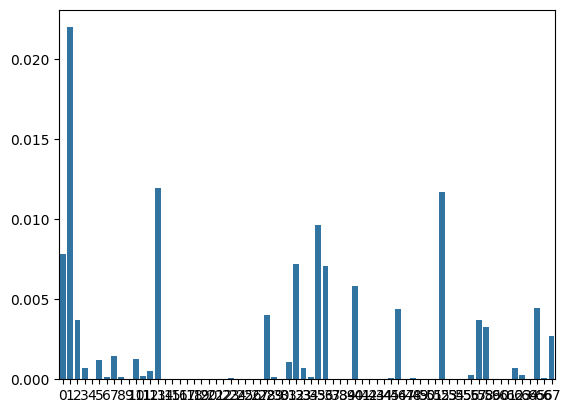

In [4]:
sns.barplot(feature_importance)

<Axes: >

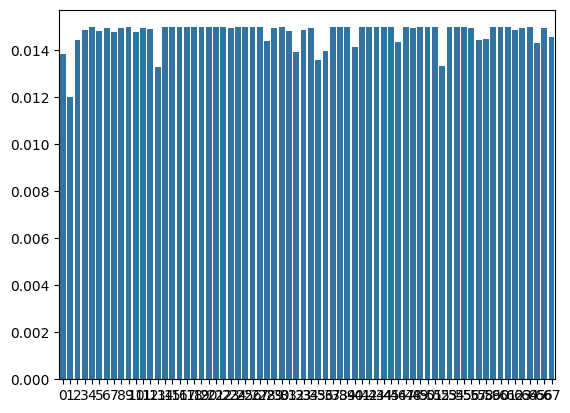

In [5]:
feature_weights = compute_feature_weights_with_temperature(0.1, feature_importance)
sns.barplot(feature_weights)

In [6]:
seed = 5
max_features = "sqrt"
sample_weights = np.ones(len(N)) / len(N)
n_estimators=100

feature_weights_list = []
# budgets = [None, 0.1, 0.01, 0.005, 0.001]
# budgets = [None, 0.1, 0.05, 0.01, 0.005]
budgets = [None, 0.1, 0.05, 0.01, 0.005, 0.001]
for budget in budgets:
    feature_weights = compute_feature_weights_with_temperature(budget, feature_importance)
    feature_weights_list.append(feature_weights)

In [10]:
for i, budget in enumerate(budgets):
    auroc = compute_test_metrics_fw_mrs(
        dropped_N,
        R,
        columns,
        random_state=seed,
        feature_weights=feature_weights_list[i],
        method=train_feature_weighted_random_forest,
        class_weight="balanced",
        max_features="sqrt",
        splitter="feature_weighted_best",
        n_splits_test=10,
        n_estimators=200,
        draw_with_feature_weights=True,
    )
    print(f"{budget}: {auroc}")

None: 0.6133544546850997
0.1: 0.6112516705656318
0.05: 0.6092279197611765
0.01: 0.6098019425536811
0.005: 0.6005382010503718
0.001: 0.5750669283201096


None: 0.736641852770885\
0.1: 0.7363564929693963\
0.05: 0.7360835401157982\
0.01: 0.7117038875103391\
0.005: 0.7074276261373036

In [9]:
for i,budget in enumerate(budgets):
    auroc, auprc, _, _, _, _ = compute_classification_metrics_random_forest(
            N,
            R,
            R,
            columns,
            sample_weights,
            feature_weights_list[i],
            target,
            random_state=seed,
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=200,
            draw_with_feature_weights=True,
            compute_feature_importance=False,
            max_features="sqrt",
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.8471589478943736
None AUPRC: 0.8024432486721023

0.1 Auroc: 0.8480543196364416
0.1 AUPRC: 0.8050165439727345

0.05 Auroc: 0.8454356703579357
0.05 AUPRC: 0.8003006938894346

0.01 Auroc: 0.818019137162185
0.01 AUPRC: 0.7659960768721192

0.005 Auroc: 0.7884245965505021
0.005 AUPRC: 0.7439043885818408

0.001 Auroc: 0.7022718336086236
0.001 AUPRC: 0.6409863095316449



None Auroc: 0.8471589478943736\
None AUPRC: 0.8024432486721023

0.1 Auroc: 0.8480543196364416\
0.1 AUPRC: 0.8050165439727345

0.05 Auroc: 0.8454356703579357\
0.05 AUPRC: 0.8003006938894346

0.01 Auroc: 0.818019137162185\
0.01 AUPRC: 0.7659960768721192

0.005 Auroc: 0.7884245965505021\
0.005 AUPRC: 0.7439043885818408

0.001 Auroc: 0.7022718336086236\
0.001 AUPRC: 0.6409863095316449